# Statistika - Cvičení 2 (Dataset Wine)

Analýza datasetu chemických parametrů vín ze **scikit-learn** (`load_wine`):
1. Výpočet průměru a mediánu pro všech 13 proměnných
2. Minimum, maximum a směrodatná odchylka pro `alcohol` a `malic_acid`
3. První a třetí kvartil (Q1 a Q3) pro `total_phenols` a `proline`
4. Výpočet korelační matice a její vizualizace pomocí Seaborn a Plotly

## 0. Načtení dat ze scikit-learn

In [1]:
from sklearn.datasets import load_wine
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

wine_data = load_wine()
wine_df = pd.DataFrame(data=wine_data.data, columns=wine_data.feature_names)
print(f"Rozměry datasetu: {wine_df.shape[0]} řádků, {wine_df.shape[1]} sloupců")
wine_df.head(3)

Rozměry datasetu: 178 řádků, 13 sloupců


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0


## 1. Průměr a medián pro každou proměnnou

In [2]:
mean_median_summary = pd.DataFrame({
    'Mean (Průměr)': wine_df.mean(),
    'Median (Medián)': wine_df.median()
}).round(3)

mean_median_summary

,Mean (Průměr),Median (Medián)
alcohol,13.001,13.050
malic_acid,2.336,1.865
ash,2.367,2.360
alcalinity_of_ash,19.495,19.500
magnesium,99.742,98.000
total_phenols,2.295,2.355
flavanoids,2.029,2.135
nonflavanoid_phenols,0.362,0.340
proanthocyanins,1.591,1.555
color_intensity,5.058,4.690


## 2. Min, Max a Směrodatná odchylka pro alcohol a malic_acid

In [3]:
alc_malic_stats = wine_df[['alcohol', 'malic_acid']].agg(['min', 'max', 'std']).T
alc_malic_stats.columns = ['Minimum', 'Maximum', 'Standard Deviation']
alc_malic_stats.round(3)

,Minimum,Maximum,Standard Deviation
alcohol,11.03,14.83,0.812
malic_acid,0.74,5.80,1.117


## 3. První a třetí kvartil pro total_phenols a proline

In [4]:
quantiles_df = wine_df[['total_phenols', 'proline']].quantile([0.25, 0.75]).T
quantiles_df.columns = ['1st Quartile (Q1 / 25%)', '3rd Quartile (Q3 / 75%)']
quantiles_df.round(3)

,1st Quartile (Q1 / 25%),3rd Quartile (Q3 / 75%)
total_phenols,1.742,2.8
proline,500.500,985.0


## 4. Korelační matice a vizualizace (Seaborn)

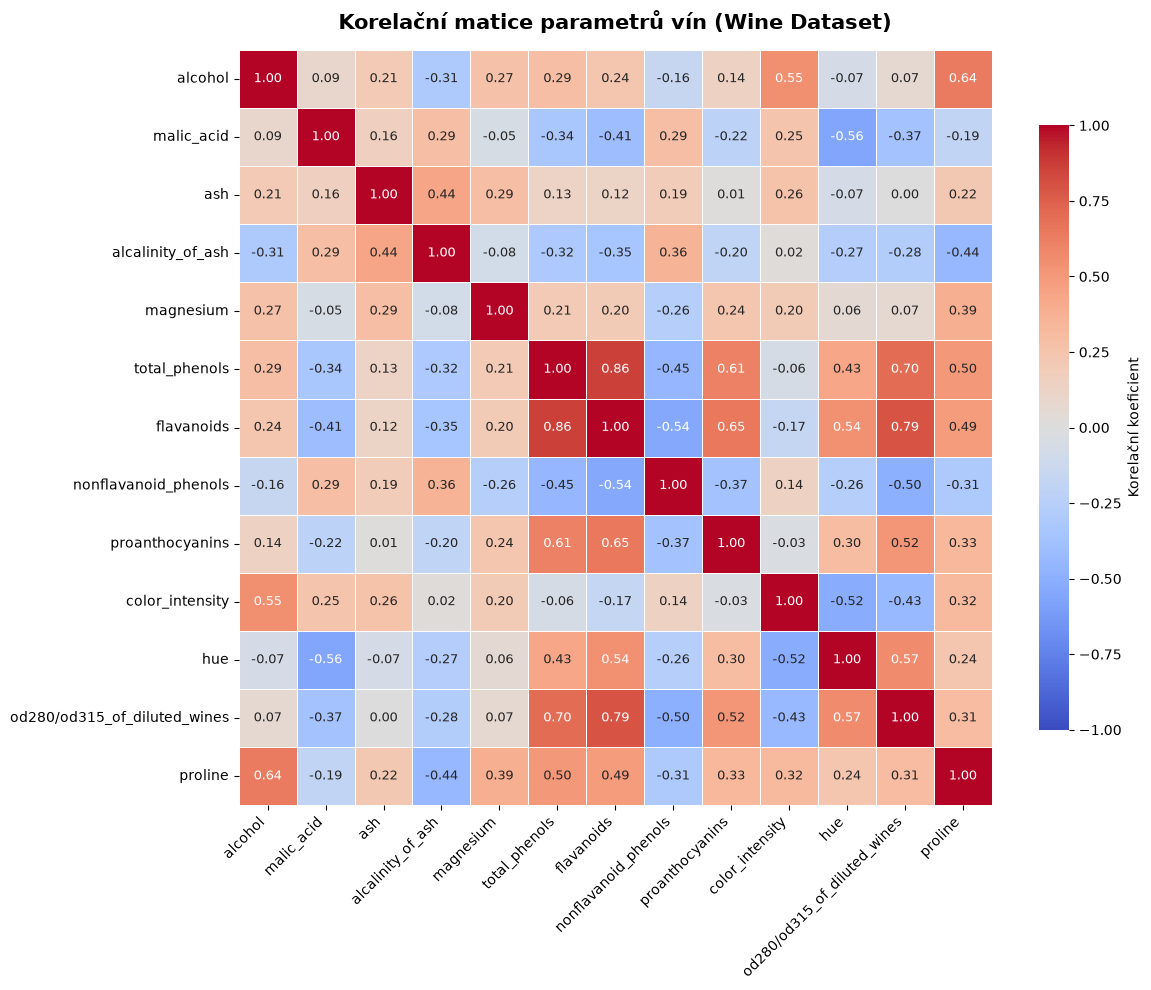

In [5]:
corr_matrix = wine_df.corr().round(2)

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Korelační koeficient', 'shrink': 0.8},
    annot_kws={'size': 9}
)
plt.title('Korelační matice parametrů vín (Wine Dataset)', fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

## 5. Interaktivní korelační matice (Plotly)

In [6]:
fig = px.imshow(
    corr_matrix,
    text_auto='.2f',
    aspect='auto',
    color_continuous_scale='RdBu_r',
    zmin=-1,
    zmax=1,
    title='Interactive Correlation Heatmap (Wine Dataset)',
    labels=dict(x='Vlastnosti', y='Vlastnosti', color='Korelace')
)
fig.update_layout(width=900, height=800, xaxis_tickangle=-45)
fig.show()